In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="7bxf8ZNtpeQlWaIVul0t")
project = rf.workspace("kolzek").project("face-anti-spoofing-ezpqo")
version = project.version(4)
dataset = version.download("coco")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.7/88.7 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 88.8 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.10
    Uninstalling idna-3.10:
      Successfully uninstalled idna-3.10
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Face-Anti-Spoofing-4 in coco:: 100%|██████████| 1128/1128 [00:00<00:00, 2721.53it/s]


In [ ]:
!pip install -q pycocotools matplotlib pandas opencv-python-headless

In [ ]:
DATA_ROOT = '/content/Face-Anti-Spoofing-4'

In [ ]:
import os, json, random, math, itertools
from collections import Counter, defaultdict
import cv2, matplotlib.pyplot as plt, numpy as np, pandas as pd
from pycocotools.coco import COCO

In [ ]:
random.seed(42)
plt.rcParams["figure.figsize"] = (10,6)

In [ ]:
def find_annotation_file(split_dir):
    # try common names
    candidates = ['annotations.json', 'instances.json', f'instances_{os.path.basename(split_dir)}.json',
                  'annotations/instances_train.json', 'annotations.json']
    for c in candidates:
        p = os.path.join(split_dir, c)
        if os.path.exists(p):
            return p
    # fallback: any .json in folder
    for f in os.listdir(split_dir):
        if f.lower().endswith('.json'):
            return os.path.join(split_dir, f)
    return None

In [ ]:
splits = {}
for s in ['train','valid','val','test','training','validation']:
    p = os.path.join(DATA_ROOT, s)
    if os.path.exists(p):
        splits[s] = p

In [ ]:
if not splits:
    for f in os.listdir(DATA_ROOT):
        candidate = os.path.join(DATA_ROOT, f)
        if os.path.isdir(candidate):
            splits[f] = candidate

In [ ]:
print("Detected split folders:", splits)
if not splits:
    raise SystemExit("No split folders found. Set DATA_ROOT to your dataset folder containing train/valid/test.")

Detected split folders: {'train': '/content/Face-Anti-Spoofing-4/train', 'valid': '/content/Face-Anti-Spoofing-4/valid', 'test': '/content/Face-Anti-Spoofing-4/test'}


In [ ]:
coco_objs = {}
for name, path in splits.items():
    ann = find_annotation_file(path)
    if ann:
        try:
            coco = COCO(ann)
            coco_objs[name] = {'coco': coco, 'ann_file': ann, 'img_dir': path}
            print(f"Loaded COCO for {name}: {ann}")
        except Exception as e:
            print("Failed loading COCO for", name, e)
    else:
        # if no json, check for images only
        coco_objs[name] = {'coco': None, 'ann_file': None, 'img_dir': path}
        print(f"No JSON found for {name}, using images at {path}")

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Loaded COCO for train: /content/Face-Anti-Spoofing-4/train/_annotations.coco.json
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loaded COCO for valid: /content/Face-Anti-Spoofing-4/valid/_annotations.coco.json
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loaded COCO for test: /content/Face-Anti-Spoofing-4/test/_annotations.coco.json


In [ ]:
def show_image_with_annotations(coco_obj, image_id=None, img_path_override=None, ax=None):
    coco = coco_obj['coco']
    img_dir = coco_obj['img_dir']
    if coco is None:
        # choose random image file from folder
        img_files = [f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))]
        if not img_files:
            raise FileNotFoundError("No images in folder " + img_dir)
        fname = random.choice(img_files) if image_id is None else image_id
        img_path = os.path.join(img_dir, fname)
        img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        if ax is None:
            plt.imshow(img); plt.axis('off'); return
        ax.imshow(img); ax.axis('off'); return

    # coco present
    if image_id is None:
        imgs = coco.getImgIds()
        if not imgs:
            raise ValueError("No images in COCO")
        image_id = random.choice(imgs)
    img_meta = coco.loadImgs(image_id)[0]
    file_name = img_meta['file_name']
    img_path = img_path_override if img_path_override else os.path.join(img_dir, file_name)
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    anns = coco.getAnnIds(imgIds=image_id, iscrowd=None)
    anns = coco.loadAnns(anns)
    if ax is None:
        fig, ax = plt.subplots(figsize=(10,8))
    ax.imshow(img)
    ax.axis('off')
    for a in anns:
        if 'bbox' in a:
            x,y,w,h = a['bbox']
            rect = plt.Rectangle((x,y), w, h, linewidth=2, edgecolor='r', facecolor='none')
            ax.add_patch(rect)
            # label
            if 'category_id' in a:
                cat = coco.loadCats([a['category_id']])[0]['name']
                ax.text(x, y-6, f"{cat} {a.get('score','')}", color='yellow', fontsize=10, weight='bold',
                        bbox=dict(facecolor='red', alpha=0.3, pad=1, edgecolor='none'))
    return ax


=== train ===


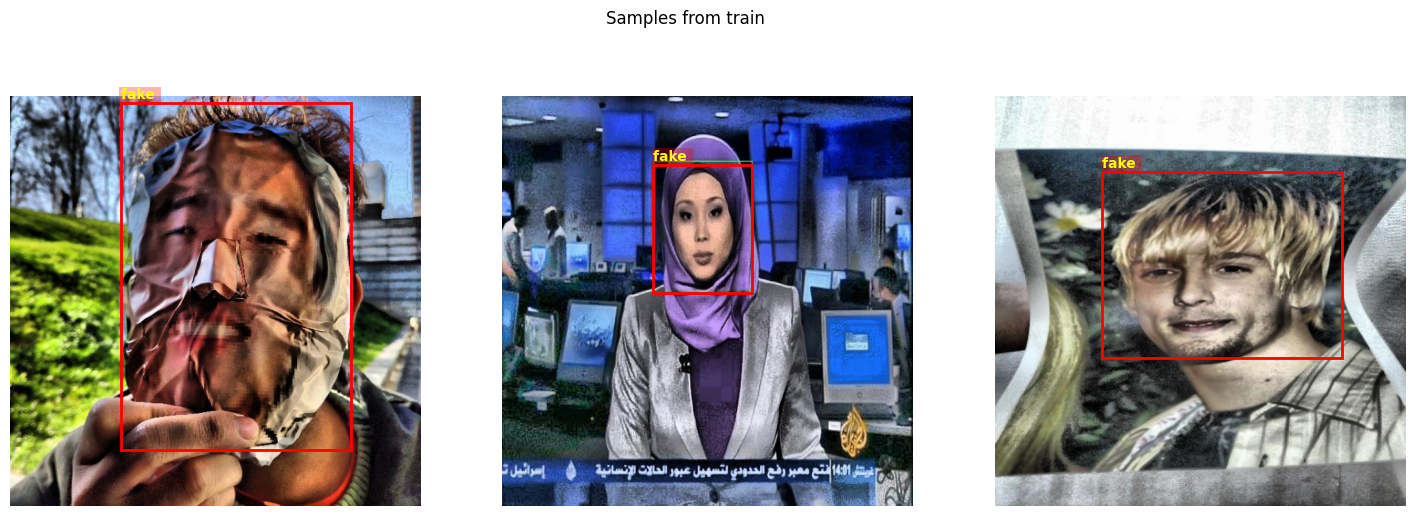


=== valid ===


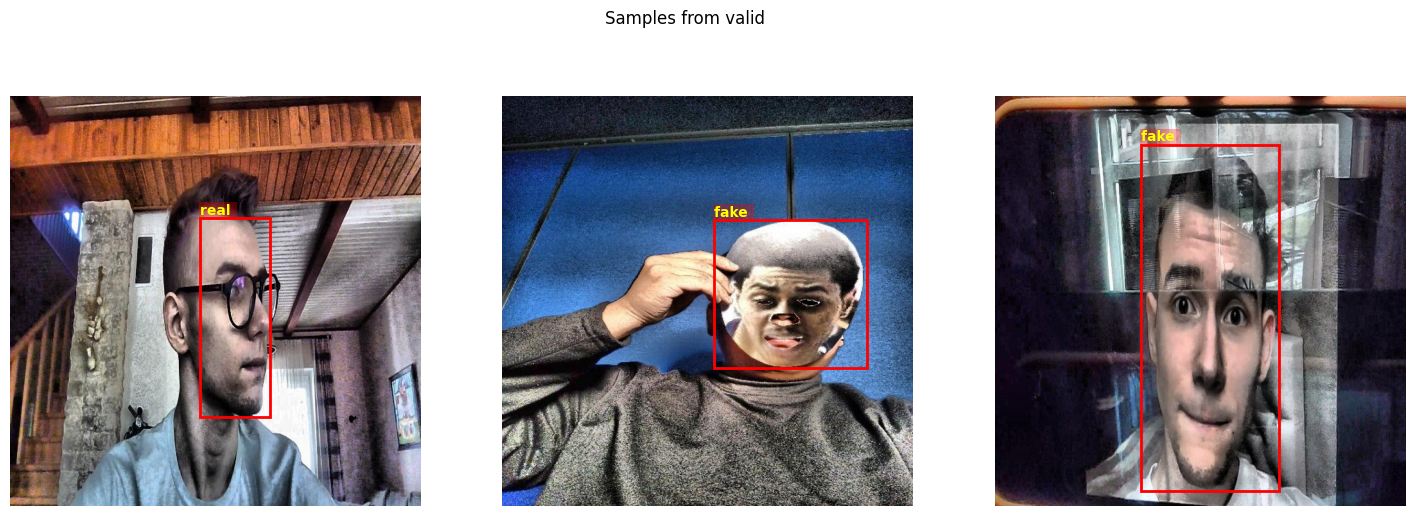


=== test ===


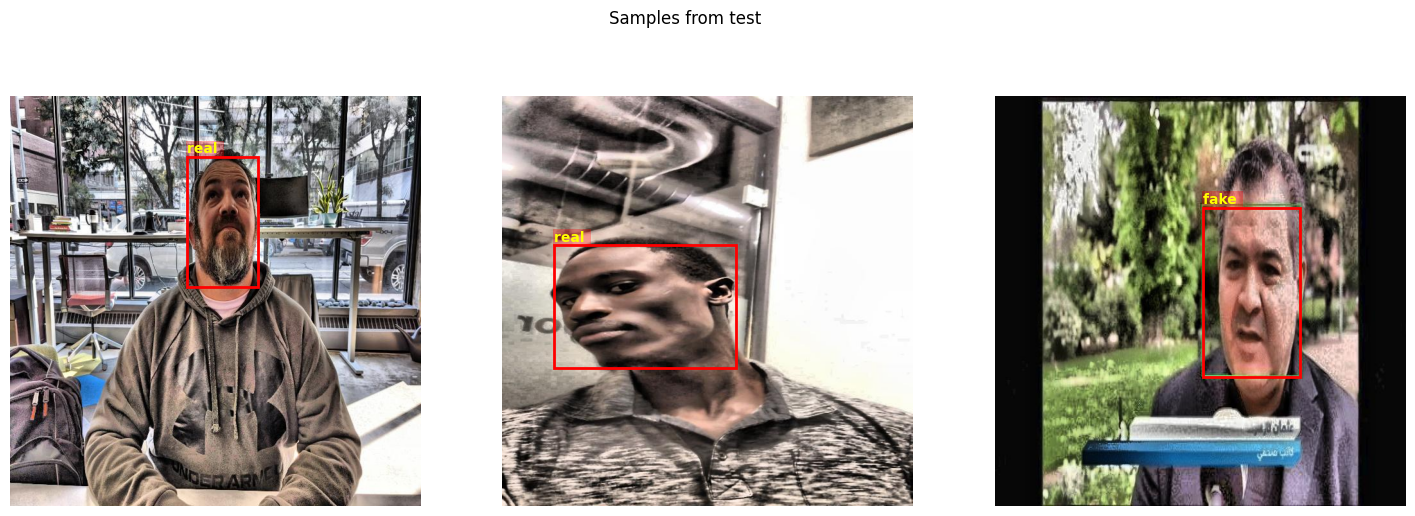

In [ ]:
for split_name, coco_obj in coco_objs.items():
    print("\n===", split_name, "===")
    fig, axs = plt.subplots(1,3, figsize=(18,6))
    for i in range(3):
        try:
            show_image_with_annotations(coco_obj, ax=axs[i])
        except Exception as e:
            axs[i].text(0.5,0.5,str(e),ha='center')
            axs[i].axis('off')
    plt.suptitle(f"Samples from {split_name}")
    plt.show()

In [ ]:
rows = []
for split_name, coco_obj in coco_objs.items():
    coco = coco_obj['coco']
    if coco is None:
        imgs = [f for f in os.listdir(coco_obj['img_dir']) if f.lower().endswith(('.jpg','.jpeg','.png'))]
        rows.append({'split': split_name, 'images': len(imgs), 'annotations': None, 'categories': None})
    else:
        img_ids = coco.getImgIds()
        ann_ids = coco.getAnnIds()
        cats = coco.loadCats(coco.getCatIds())
        rows.append({'split': split_name, 'images': len(img_ids), 'annotations': len(ann_ids),
                     'categories': ','.join([c['name'] for c in cats])})
df_stats = pd.DataFrame(rows)
display(df_stats)

,split,images,annotations,categories
0,train,887,932,"real-face-fake-face,fake,real"
1,valid,135,150,"real-face-fake-face,fake,real"
2,test,98,169,"real-face-fake-face,fake,real"


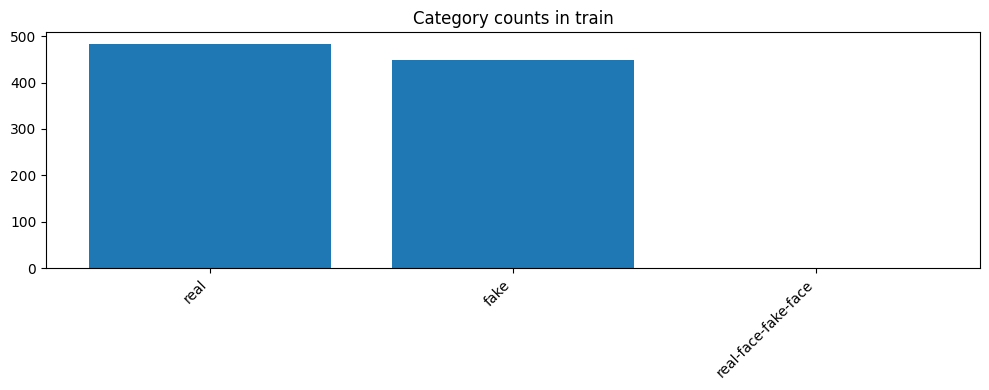

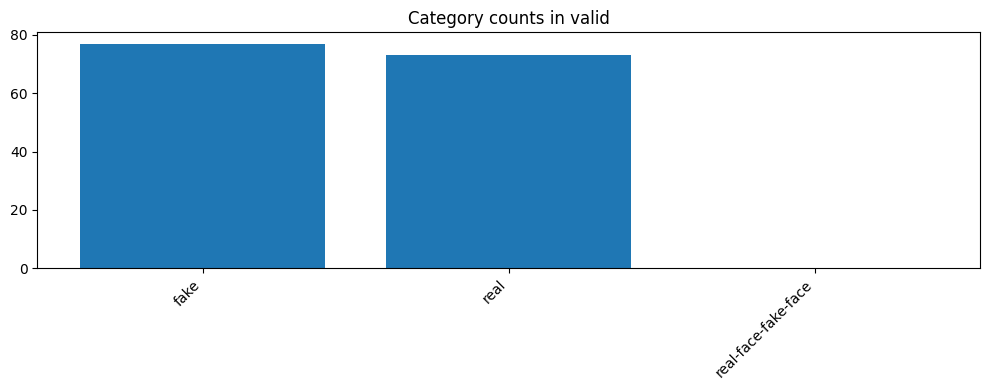

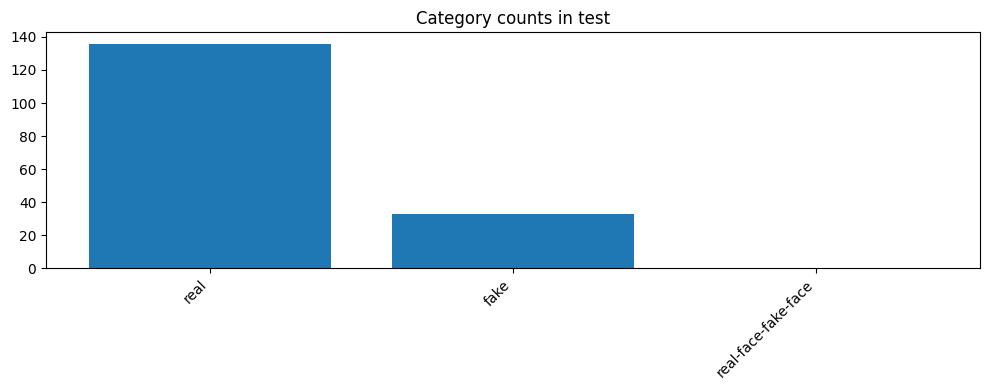

In [ ]:
for split_name, coco_obj in coco_objs.items():
    coco = coco_obj['coco']
    if coco is None:
        continue
    cat_ids = coco.getCatIds()
    cat_map = {c['id']: c['name'] for c in coco.loadCats(cat_ids)}
    counts = Counter()
    for cid in cat_ids:
        ann_ids = coco.getAnnIds(catIds=[cid])
        counts[cat_map[cid]] = len(ann_ids)
    if not counts:
        continue
    names = list(counts.keys()); vals = [counts[n] for n in names]
    sidx = np.argsort(vals)[::-1]
    plt.figure(figsize=(10,4))
    plt.bar(np.array(names)[sidx], np.array(vals)[sidx])
    plt.xticks(rotation=45, ha='right')
    plt.title(f"Category counts in {split_name}")
    plt.tight_layout()
    plt.show()

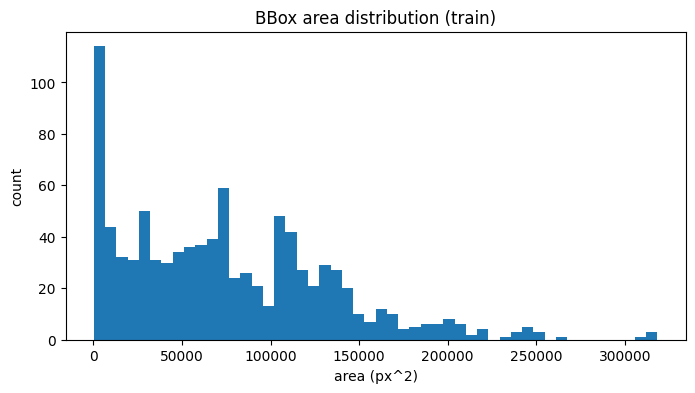

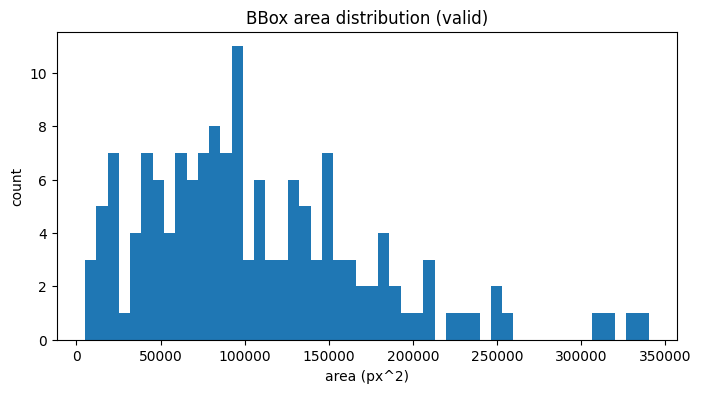

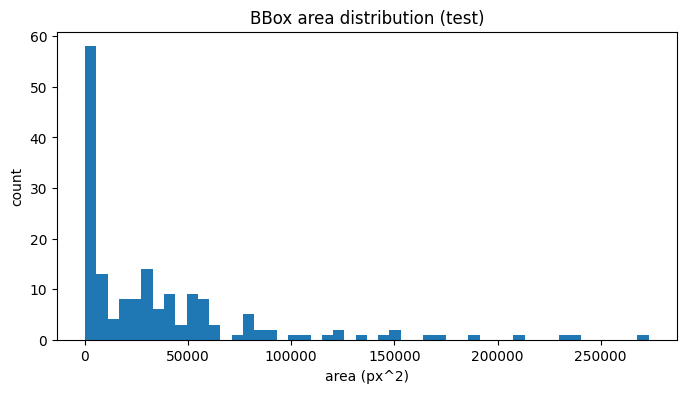

In [ ]:
for split_name, coco_obj in coco_objs.items():
    coco = coco_obj['coco']
    if coco is None: continue
    ann_ids = coco.getAnnIds()
    areas = []
    for a in coco.loadAnns(ann_ids):
        if 'bbox' in a:
            _,_,w,h = a['bbox']
            areas.append(w*h)
    if not areas: continue
    areas = np.array(areas)
    plt.figure(figsize=(8,4))
    plt.hist(areas, bins=50)
    plt.title(f"BBox area distribution ({split_name})")
    plt.xlabel("area (px^2)")
    plt.ylabel("count")
    plt.show()

In [ ]:
import os, random, math, pandas as pd, numpy as np
import tensorflow as tf
from pycocotools.coco import COCO
import cv2
random.seed(42)
IMG_SIZE = (224,224)
BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE
OUT_WORKDIR = "/content/securevision_face_spoof"
os.makedirs(OUT_WORKDIR, exist_ok=True)

In [ ]:
all_rows = {"split":[], "file":[], "label":[]}

In [ ]:
def infer_label_from_coco(coco, img_id):
    # if dataset categories are explicit (e.g., 'real','fake'), use them
    ann_ids = coco.getAnnIds(imgIds=img_id)
    anns = coco.loadAnns(ann_ids)
    if not anns:
        return None
    # collect category names present
    cats = set()
    for a in anns:
        cid = a.get('category_id', None)
        if cid is None: continue
        cats.add(coco.loadCats([cid])[0]['name'].lower())
    # if exactly one distinct category, return it
    if len(cats)==1:
        return list(cats)[0]
    # else prefer any known tokens
    for c in cats:
        if 'fake' in c or 'spoof' in c or 'attack' in c or 'deep' in c:
            return c
    for c in cats:
        if 'real' in c or 'live' in c or 'genuine' in c:
            return c
    # fallback: return first
    return list(cats)[0]

for split_name, coco_obj in coco_objs.items():
    img_dir = coco_obj['img_dir']
    coco = coco_obj['coco']
    if coco is None:
        # walk directory; use parent folder as label if images are in class subfolders
        for root, _, files in os.walk(img_dir):
            for f in files:
                if not f.lower().endswith(('.jpg','.jpeg','.png')): continue
                full = os.path.join(root, f)
                # determine label by parent folder relative to img_dir
                rel = os.path.relpath(root, img_dir)
                if rel != ".":
                    label = rel.split(os.sep)[0].lower()
                else:
                    # fallback heuristics on filename
                    nm = f.lower()
                    label = "fake" if any(t in nm for t in ("fake","spoof","attack","deepfake")) else "real"
                all_rows["split"].append(split_name)
                all_rows["file"].append(full)
                all_rows["label"].append(label)
    else:
        for img_id in coco.getImgIds():
            meta = coco.loadImgs([img_id])[0]
            fname = meta['file_name']
            full = os.path.join(img_dir, fname)
            if not os.path.exists(full):
                # try images/ subfolder
                alt = os.path.join(img_dir, "images", fname)
                if os.path.exists(alt):
                    full = alt
                else:
                    continue
            label = infer_label_from_coco(coco, img_id)
            if label is None:
                # fallback to filename heuristic
                nm = fname.lower()
                label = "fake" if any(t in nm for t in ("fake","spoof","attack","deepfake")) else "real"
            all_rows["split"].append(split_name)
            all_rows["file"].append(full)
            all_rows["label"].append(label.lower())

In [ ]:
df = pd.DataFrame(all_rows)
print("Raw label classes found:", df['label'].unique())
# Map labels to binary classes: prefer explicit 'real' vs 'fake' tokens; otherwise take two most common classes and map first=>real second=>fake
labels_unique = list(df['label'].value_counts().index)
if set(['real','fake']).issubset(set(labels_unique)):
    label_map = {'real': 'real', 'fake':'fake'}
else:
    # pick top-2 as proxies
    top2 = labels_unique[:2] if len(labels_unique)>=2 else labels_unique + ["other"]
    label_map = {top2[0]: 'real', top2[1]: 'fake'}
    # any other label map to 'real' by default
    for l in labels_unique:
        if l not in label_map:
            label_map[l] = 'real'
df['label_bin'] = df['label'].map(label_map)
print("Mapping used:", label_map)
display(df.head())

Raw label classes found: ['fake' 'real']
Mapping used: {'real': 'real', 'fake': 'fake'}


,split,file,label,label_bin
0,train,/content/Face-Anti-Spoofing-4/train/534207_png...,fake,fake
1,train,/content/Face-Anti-Spoofing-4/train/tumblr_n9s...,real,real
2,train,/content/Face-Anti-Spoofing-4/train/skypost160...,real,real
3,train,/content/Face-Anti-Spoofing-4/train/IMG_4921-2...,real,real
4,train,/content/Face-Anti-Spoofing-4/train/251077_jpg...,fake,fake


In [ ]:
train_df = df[df['split'].str.contains('train', case=False, na=False)]
val_df = df[df['split'].str.contains('val', case=False, na=False) | df['split'].str.contains('valid', case=False, na=False)]
# if val empty, create val by splitting train
if val_df.empty:
    train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)
    n_val = max(1, int(0.2 * len(train_df)))
    val_df = train_df.iloc[:n_val].copy()
    train_df = train_df.iloc[n_val:].copy()

print("train/val sizes:", len(train_df), len(val_df))

train/val sizes: 887 135


In [ ]:
def path_label_to_ds(df_in, shuffle=True):
    paths = df_in['file'].tolist()
    labels = (df_in['label_bin']=='real').astype(int).tolist()  # 1 -> real, 0 -> fake
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=42)
    def _load(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_image(img, channels=3, expand_animations=False)
        img = tf.image.convert_image_dtype(img, tf.float32)
        img = tf.image.resize(img, IMG_SIZE)
        return img, label
    ds = ds.map(_load, num_parallel_calls=AUTOTUNE)
    return ds

In [ ]:
train_ds = path_label_to_ds(train_df, shuffle=True).batch(BATCH_SIZE).prefetch(AUTOTUNE)
val_ds   = path_label_to_ds(val_df, shuffle=False).batch(BATCH_SIZE).prefetch(AUTOTUNE)

In [ ]:
DATA_IMG_FOLDER = os.path.join(OUT_WORKDIR, "images_by_label")

In [ ]:
for x,y in train_ds.take(1):
    print("batch images:", x.shape, "labels:", y.numpy()[:8])

batch images: (16, 224, 224, 3) labels: [0 1 1 0 0 0 0 1]


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
y_train = (train_df['label_bin']=='real').astype(int).values
classes = np.unique(y_train)
cw = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight = {int(classes[i]): float(cw[i]) for i in range(len(classes))}
print("class_weight:", class_weight)

class_weight: {0: 1.0242494226327945, 1: 0.9768722466960352}


In [ ]:
# Fix for the 'KerasTensor' AttributeError — correct EfficientNet wiring
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

def make_model(img_size=IMG_SIZE + (3,), lr=1e-4):
    inp = layers.Input(shape=img_size)
    # model expects 0-255 preprocessing, our inputs are 0-1 -> multiply then call preprocess_input
    x = layers.Lambda(lambda z: preprocess_input(z * 255.0))(inp)
    # create base model separately, then call it on x
    base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=img_size)
    base_model.trainable = False
    base_out = base_model(x)                # returns a tensor
    x = layers.GlobalAveragePooling2D()(base_out)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    model = models.Model(inputs=inp, outputs=out)
    model.compile(optimizer=tf.keras.optimizers.Adam(lr),
                  loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.AUC()])
    return model

# recreate model and show summary
model = make_model()
model.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,668 (16.07 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='best_model.h5',
        monitor='val_auc',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

In [ ]:
EPOCHS = 20
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - accuracy: 0.6315 - auc_2: 0.6736 - loss: 0.6505

Can save best model only with val_auc available.


56/56 ━━━━━━━━━━━━━━━━━━━━ 47s 463ms/step - accuracy: 0.6327 - auc_2: 0.6752 - loss: 0.6494 - val_accuracy: 0.8667 - val_auc_2: 0.9388 - val_loss: 0.5065 - learning_rate: 1.0000e-04
Epoch 2/20
55/56 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.7944 - auc_2: 0.8780 - loss: 0.4620

56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step - accuracy: 0.7953 - auc_2: 0.8790 - loss: 0.4608 - val_accuracy: 0.8519 - val_auc_2: 0.9552 - val_loss: 0.4370 - learning_rate: 1.0000e-04
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8766 - auc_2: 0.9392 - loss: 0.3599

56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.8767 - auc_2: 0.9395 - loss: 0.3595 - val_accuracy: 0.8296 - val_auc_2: 0.9579 - val_loss: 0.4189 - learning_rate: 1.0000e-04
Epoch 4/20
55/56 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8902 - auc_2: 0.9704 - loss: 0.2822

...

56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step - accuracy: 0.9675 - auc_2: 0.9962 - loss: 0.0975 - val_accuracy: 0.8593 - val_auc_2: 0.9779 - val_loss: 0.3463 - learning_rate: 1.0000e-04
Epoch 17/20
55/56 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9720 - auc_2: 0.9968 - loss: 0.0892

56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.9719 - auc_2: 0.9968 - loss: 0.0895 - val_accuracy: 0.8889 - val_auc_2: 0.9764 - val_loss: 0.2704 - learning_rate: 1.0000e-04
Epoch 18/20
55/56 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9764 - auc_2: 0.9973 - loss: 0.0815

56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.9762 - auc_2: 0.9972 - loss: 0.0820 - val_accuracy: 0.8741 - val_auc_2: 0.9771 - val_loss: 0.2953 - learning_rate: 1.0000e-04
Epoch 19/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.9691 - auc_2: 0.9969 - loss: 0.0950

56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - accuracy: 0.9690 - auc_2: 0.9968 - loss: 0.0951 - val_accuracy: 0.8889 - val_auc_2: 0.9784 - val_loss: 0.2568 - learning_rate: 1.0000e-04
Epoch 20/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9626 - auc_2: 0.9965 - loss: 0.0930

56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.9627 - auc_2: 0.9965 - loss: 0.0930 - val_accuracy: 0.8889 - val_auc_2: 0.9791 - val_loss: 0.2749 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 19.


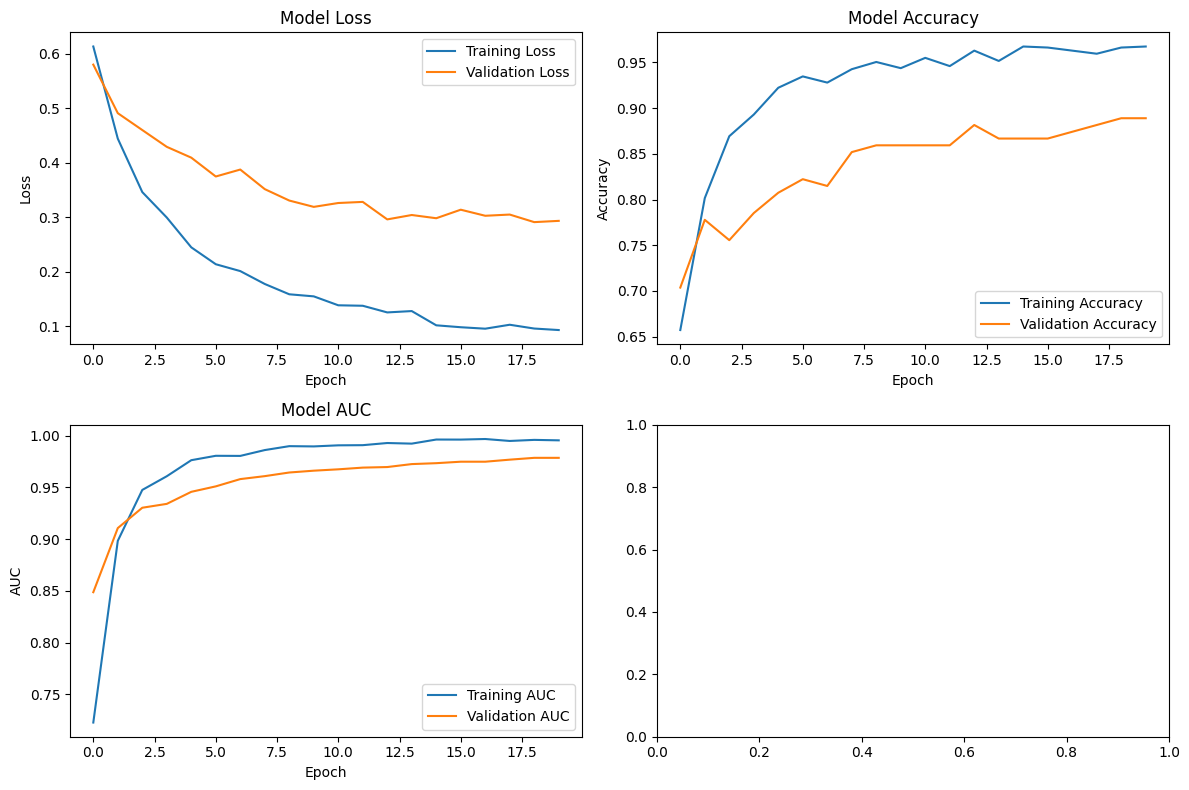

In [ ]:
# Plot training history
import matplotlib.pyplot as plt

def plot_training_history(history):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    # Loss
    axes[0,0].plot(history.history['loss'], label='Training Loss')
    axes[0,0].plot(history.history['val_loss'], label='Validation Loss')
    axes[0,0].set_title('Model Loss')
    axes[0,0].set_xlabel('Epoch')
    axes[0,0].set_ylabel('Loss')
    axes[0,0].legend()

    # Accuracy
    axes[0,1].plot(history.history['accuracy'], label='Training Accuracy')
    axes[0,1].plot(history.history['val_accuracy'], label='Validation Accuracy')
    axes[0,1].set_title('Model Accuracy')
    axes[0,1].set_xlabel('Epoch')
    axes[0,1].set_ylabel('Accuracy')
    axes[0,1].legend()

    # AUC
    axes[1,0].plot(history.history['auc'], label='Training AUC')
    axes[1,0].plot(history.history['val_auc'], label='Validation AUC')
    axes[1,0].set_title('Model AUC')
    axes[1,0].set_xlabel('Epoch')
    axes[1,0].set_ylabel('AUC')
    axes[1,0].legend()

    # Learning Rate
    if 'lr' in history.history:
        axes[1,1].plot(history.history['lr'], label='Learning Rate')
        axes[1,1].set_title('Learning Rate')
        axes[1,1].set_xlabel('Epoch')
        axes[1,1].set_ylabel('LR')
        axes[1,1].set_yscale('log')
        axes[1,1].legend()

    plt.tight_layout()
    plt.show()

plot_training_history(history)

In [ ]:
model.load_weights('best_model.h5')

# Evaluation on validation set
val_loss, val_acc, val_auc = model.evaluate(val_ds, verbose=0)
print(f"Validation Results - Loss: {val_loss:.4f}, Accuracy: {val_acc:.4f}, AUC: {val_auc:.4f}")

Validation Results - Loss: 0.2911, Accuracy: 0.8889, AUC: 0.9786


In [ ]:
def predict_single_image(model, image_path, img_size=IMG_SIZE):
    """Predict on a single image"""
    # Load and preprocess image
    img = tf.io.read_file(image_path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.convert_image_dtype(img, tf.float32)
    img = tf.image.resize(img, img_size)
    img = tf.expand_dims(img, 0)  # Add batch dimension

    # Predict
    pred = model.predict(img, verbose=0)[0][0]
    label = "Real" if pred > 0.5 else "Fake"
    confidence = pred if pred > 0.5 else 1 - pred

    return {
        'prediction': label,
        'confidence': float(confidence),
        'raw_score': float(pred)
    }

In [ ]:
def predict_batch(model, image_paths, img_size=IMG_SIZE, batch_size=32):
    """Predict on multiple images"""
    results = []

    for i in range(0, len(image_paths), batch_size):
        batch_paths = image_paths[i:i+batch_size]
        batch_images = []

        for path in batch_paths:
            img = tf.io.read_file(path)
            img = tf.image.decode_image(img, channels=3, expand_animations=False)
            img = tf.image.convert_image_dtype(img, tf.float32)
            img = tf.image.resize(img, img_size)
            batch_images.append(img)

        batch_images = tf.stack(batch_images)
        predictions = model.predict(batch_images, verbose=0)

        for j, pred in enumerate(predictions):
            score = pred[0]
            label = "Real" if score > 0.5 else "Fake"
            confidence = score if score > 0.5 else 1 - score

            results.append({
                'image_path': batch_paths[j],
                'prediction': label,
                'confidence': float(confidence),
                'raw_score': float(score)
            })

    return results

In [ ]:
test_df = df[df['split'].str.contains('test', case=False, na=False)]
if not test_df.empty:
    test_ds = path_label_to_ds(test_df, shuffle=False).batch(BATCH_SIZE).prefetch(AUTOTUNE)

    # Evaluate on test set
    test_loss, test_acc, test_auc = model.evaluate(test_ds, verbose=0)
    print(f"Test Results - Loss: {test_loss:.4f}, Accuracy: {test_acc:.4f}, AUC: {test_auc:.4f}")

    # Get predictions and true labels for confusion matrix
    y_pred_proba = model.predict(test_ds)
    y_pred = (y_pred_proba > 0.5).astype(int)

    # Get true labels
    y_true = []
    for _, labels in test_ds:
        y_true.extend(labels.numpy())
    y_true = np.array(y_true)

    # Confusion matrix and classification report
    from sklearn.metrics import confusion_matrix, classification_report

    cm = confusion_matrix(y_true, y_pred)
    print("Confusion Matrix:")
    print(cm)

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=['Fake', 'Real']))


Test Results - Loss: 0.1282, Accuracy: 0.9592, AUC: 0.9930
7/7 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step
Confusion Matrix:
[[33  0]
 [ 4 61]]

Classification Report:
              precision    recall  f1-score   support

        Fake       0.89      1.00      0.94        33
        Real       1.00      0.94      0.97        65

    accuracy                           0.96        98
   macro avg       0.95      0.97      0.96        98
weighted avg       0.96      0.96      0.96        98



In [ ]:
model.save('deepfake_detector_final.h5')
print("Model saved as 'deepfake_detector_final.h5'")

Model saved as 'deepfake_detector_final.h5'


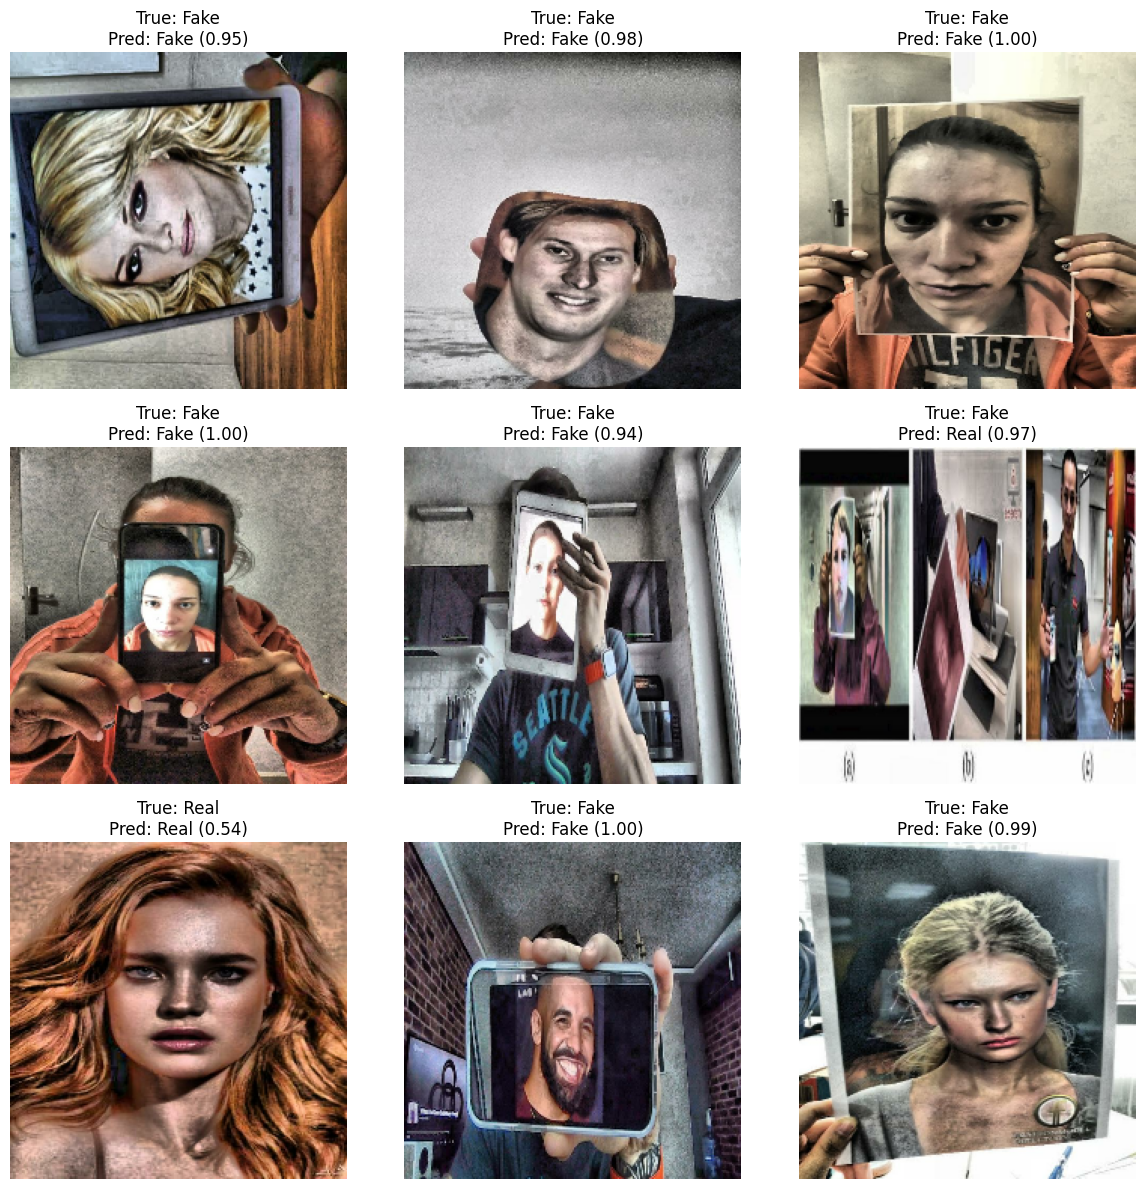

In [ ]:
def visualize_predictions(model, dataset, num_samples=9):
    """Visualize model predictions on sample images"""
    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    axes = axes.ravel()

    count = 0
    for images, labels in dataset.take(1):
        for i in range(min(num_samples, len(images))):
            img = images[i].numpy()
            true_label = "Real" if labels[i].numpy() == 1 else "Fake"

            # Predict
            pred = model.predict(tf.expand_dims(images[i], 0), verbose=0)[0][0]
            pred_label = "Real" if pred > 0.5 else "Fake"
            confidence = pred if pred > 0.5 else 1 - pred

            # Plot
            axes[count].imshow(img)
            axes[count].set_title(f"True: {true_label}\nPred: {pred_label} ({confidence:.2f})")
            axes[count].axis('off')

            count += 1
            if count >= num_samples:
                break

    plt.tight_layout()
    plt.show()

# Visualize some predictions
if not val_ds is None:
    visualize_predictions(model, val_ds)

# Deepfake detection.

In [ ]:
URL="https://data.mendeley.com/public-files/datasets/bcmkfgct2s/files/a9ef71a3-b625-4682-a21c-f0579e85cdd4/file_downloaded"
ZIPNAME="deepfake_videos.zip"
OUTDIR="/content/deepfake_dataset"

In [ ]:
! wget -q -O "$ZIPNAME" "$URL" --no-check-certificat

In [ ]:
!unzip -d /content/deepfake-dataset /content/deepfake_videos.zip

Archive:  /content/deepfake_videos.zip
   creating: /content/deepfake-dataset/SDFVD/videos_fake/
  inflating: /content/deepfake-dataset/SDFVD/videos_fake/vs1.mp4  
  inflating: /content/deepfake-dataset/SDFVD/videos_fake/vs10.mp4  
  inflating: /content/deepfake-dataset/SDFVD/videos_fake/vs11.mp4  
  inflating: /content/deepfake-dataset/SDFVD/videos_fake/vs12.mp4  
  inflating: /content/deepfake-dataset/SDFVD/videos_fake/vs13.mp4  
  inflating: /content/deepfake-dataset/SDFVD/videos_fake/vs14.mp4  
  inflating: /content/deepfake-dataset/SDFVD/videos_fake/vs15.mp4  
  inflating: /content/deepfake-dataset/SDFVD/videos_fake/vs16.mp4  
  inflating: /content/deepfake-dataset/SDFVD/videos_fake/vs17.mp4  
  inflating: /content/deepfake-dataset/SDFVD/videos_fake/vs18.mp4  
  inflating: /content/deepfake-dataset/SDFVD/videos_fake/vs19.mp4  
  inflating: /content/deepfake-dataset/SDFVD/videos_fake/vs2.mp4  
  inflating: /content/deepfake-dataset/SDFVD/videos_fake/vs20.mp4  
  inflating: /content

In [ ]:
import os, glob, cv2, math, statistics
from mtcnn.mtcnn import MTCNN
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from IPython.display import display, Image, HTML

In [ ]:
DATA_ROOT = "/content/deepfake-dataset"

In [ ]:
def find_class_dirs(root):
    for sub in ("SDFVD", ""):
        base = os.path.join(root, sub) if sub else root
        fake = os.path.join(base, "videos_fake")
        real = os.path.join(base, "videos_real")
        if os.path.exists(fake) and os.path.exists(real):
            return fake, real
    # fallback: look for folders containing 'fake'/'real'
    fake = None; real = None
    for entry in os.listdir(root):
        p = os.path.join(root, entry)
        if os.path.isdir(p):
            if "fake" in entry.lower() and fake is None: fake = p
            if "real" in entry.lower() and real is None: real = p
    return fake, real

In [ ]:
videos_fake_dir, videos_real_dir = find_class_dirs(DATA_ROOT)
if videos_fake_dir is None or videos_real_dir is None:
    raise SystemExit(f"Could not locate videos_fake/videos_real under {DATA_ROOT}. Edit DATA_ROOT accordingly.")


In [ ]:

print("videos_fake_dir:", videos_fake_dir)
print("videos_real_dir:", videos_real_dir)

videos_fake_dir: /content/deepfake-dataset/SDFVD/videos_fake
videos_real_dir: /content/deepfake-dataset/SDFVD/videos_real


In [ ]:
EXTS = ("*.mp4","*.mov","*.avi","*.mkv","*.webm")
def gather_videos(folder, limit=None):
    files=[]
    for ext in EXTS:
        files += glob.glob(os.path.join(folder, "**", ext), recursive=True)
    files = sorted(files)
    if limit:
        return files[:limit]
    return files

In [ ]:

fake_videos = gather_videos(videos_fake_dir)
real_videos = gather_videos(videos_real_dir)
print("found fake:", len(fake_videos), "real:", len(real_videos))

found fake: 53 real: 53


In [ ]:
def video_info(path):
    cap = cv2.VideoCapture(path)
    if not cap.isOpened():
        return None
    fps = cap.get(cv2.CAP_PROP_FPS) or 0.0
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT) or 0)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH) or 0)
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT) or 0)
    duration = frame_count / fps if fps>0 else 0.0
    cap.release()
    return {"path": path, "fps": fps, "frames": frame_count, "duration": duration, "width": width, "height": height}

In [ ]:

def collect_stats(file_list, nmax=200):
    stats=[]
    for p in tqdm(file_list[:nmax], desc="collecting stats"):
        info = video_info(p)
        if info:
            stats.append(info)
    return pd.DataFrame(stats)

In [ ]:
N_STATS = 200
df_fake = collect_stats(fake_videos, nmax=N_STATS)
df_real = collect_stats(real_videos, nmax=N_STATS)

collecting stats: 100%|██████████| 53/53 [00:00<00:00, 1325.66it/s]


In [ ]:
print("Counts -> fake:", len(fake_videos), "real:", len(real_videos))
display(pd.DataFrame({"class":["fake","real"], "count":[len(fake_videos), len(real_videos)]}))

Counts -> fake: 53 real: 53


,class,count
0,fake,53
1,real,53


In [ ]:
def hist_and_summary(df, title):
    if df.empty:
        print("No data for", title); return
    print(f"--- {title} summary ---")
    print(df[["duration","fps","frames","width","height"]].describe().transpose()[["count","mean","std","min","50%","max"]])
    plt.figure(figsize=(14,3))
    plt.subplot(1,3,1); plt.hist(df['duration'].dropna(), bins=30); plt.title("Duration (s)")
    plt.subplot(1,3,2); plt.hist(df['fps'].replace(0,np.nan).dropna(), bins=30); plt.title("FPS")
    plt.subplot(1,3,3); plt.hist(df['frames'].dropna(), bins=30); plt.title("Frame count")
    plt.suptitle(title)
    plt.tight_layout(); plt.show()
    # resolution scatter
    plt.figure(figsize=(6,4))
    plt.scatter(df['width'], df['height'], alpha=0.6, s=8)
    plt.xlabel("width"); plt.ylabel("height"); plt.title(f"Resolutions: {title}")
    plt.show()

--- FAKE videos summary ---
          count         mean         std         min          50%          max
duration   53.0     3.371698    0.687880    2.133333     3.333333     5.833333
fps        53.0    30.000000    0.000000   30.000000    30.000000    30.000000
frames     53.0   101.150943   20.636409   64.000000   100.000000   175.000000
width      53.0  1011.622642  412.087567  378.000000  1280.000000  1280.000000
height     53.0   710.452830   18.833855  674.000000   720.000000   720.000000


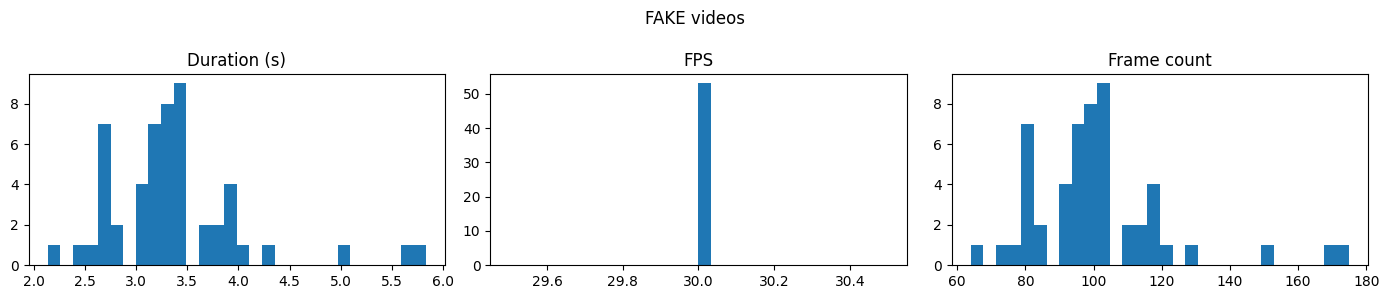

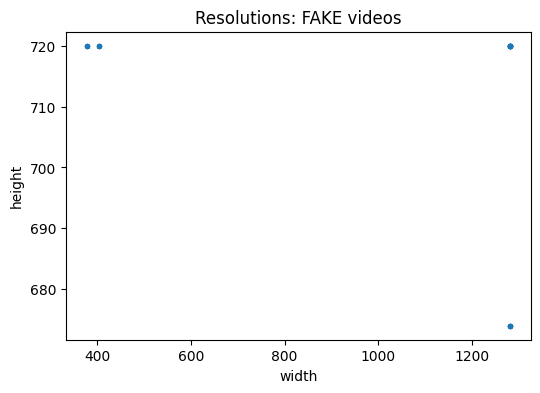

--- REAL videos summary ---
          count         mean         std         min          50%     max
duration   53.0     3.352830    0.690393    2.133333     3.333333     5.8
fps        53.0    30.000000    0.000000   30.000000    30.000000    30.0
frames     53.0   100.584906   20.711790   64.000000   100.000000   174.0
width      53.0  1011.622642  412.087567  378.000000  1280.000000  1280.0
height     53.0   710.452830   18.833855  674.000000   720.000000   720.0


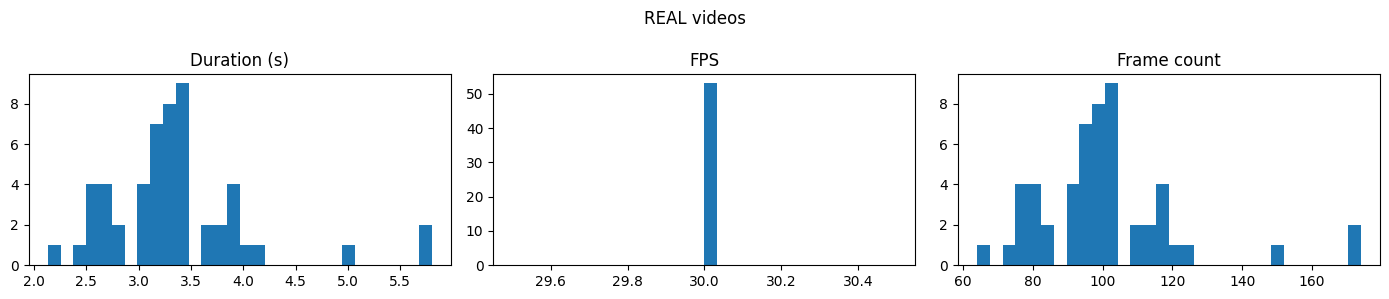

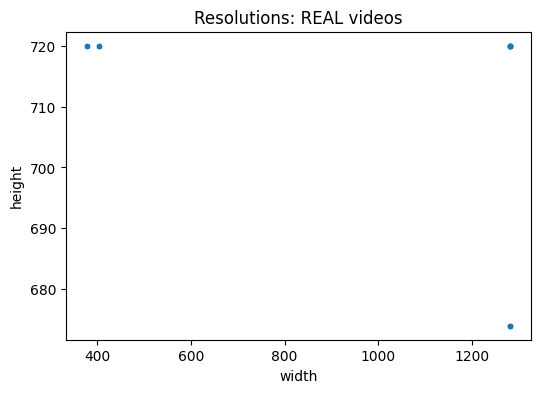

In [ ]:
hist_and_summary(df_fake, "FAKE videos")
hist_and_summary(df_real, "REAL videos")

In [ ]:
SAMPLE_VIDEOS_PER_CLASS = 5
FRAMES_PER_VIDEO = 5
SAMPLE_OUT = "/content/deepfake_samples"
os.makedirs(SAMPLE_OUT, exist_ok=True)

In [ ]:
def sample_frames_from_video(path, n_frames=5, max_width=640):
    cap = cv2.VideoCapture(path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT) or 0)
    if total == 0:
        cap.release()
        return []
    idxs = np.linspace(0, total-1, min(n_frames, total), dtype=int)
    frames=[]
    for idx in idxs:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ret, frame = cap.read()
        if not ret:
            continue
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        h,w = frame.shape[:2]
        if max(w,h) > max_width:
            scale = max_width / max(w,h)
            frame = cv2.resize(frame, (int(w*scale), int(h*scale)))
        frames.append(frame)
    cap.release()
    return frames


In [ ]:
def make_grid(images, cols=5, title=None, figsize=(16,6)):
    if not images:
        print("no images")
        return
    rows = math.ceil(len(images)/cols)
    plt.figure(figsize=figsize)
    for i,img in enumerate(images):
        plt.subplot(rows, cols, i+1)
        plt.imshow(img); plt.axis('off')
    if title:
        plt.suptitle(title)
    plt.tight_layout(); plt.show()

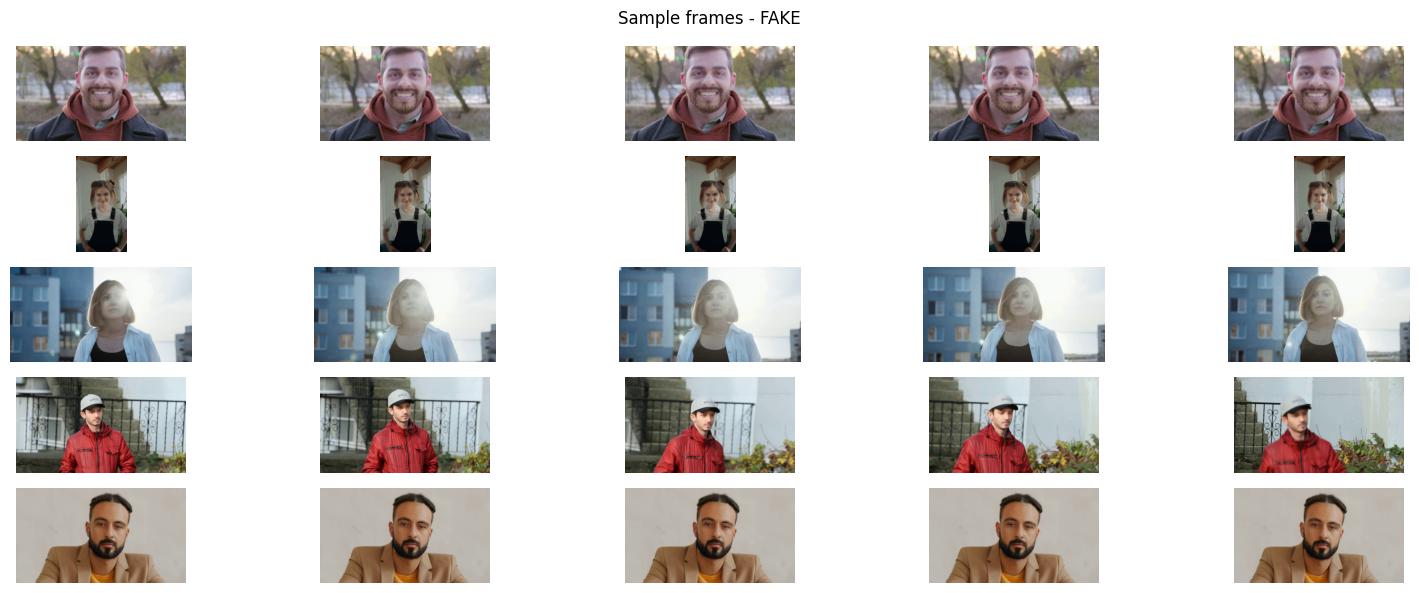

In [ ]:
fake_samples = fake_videos[:SAMPLE_VIDEOS_PER_CLASS]
all_fake_frames = []
for v in fake_samples:
    frs = sample_frames_from_video(v, n_frames=FRAMES_PER_VIDEO)
    all_fake_frames += frs
make_grid(all_fake_frames, cols=FRAMES_PER_VIDEO, title="Sample frames - FAKE")

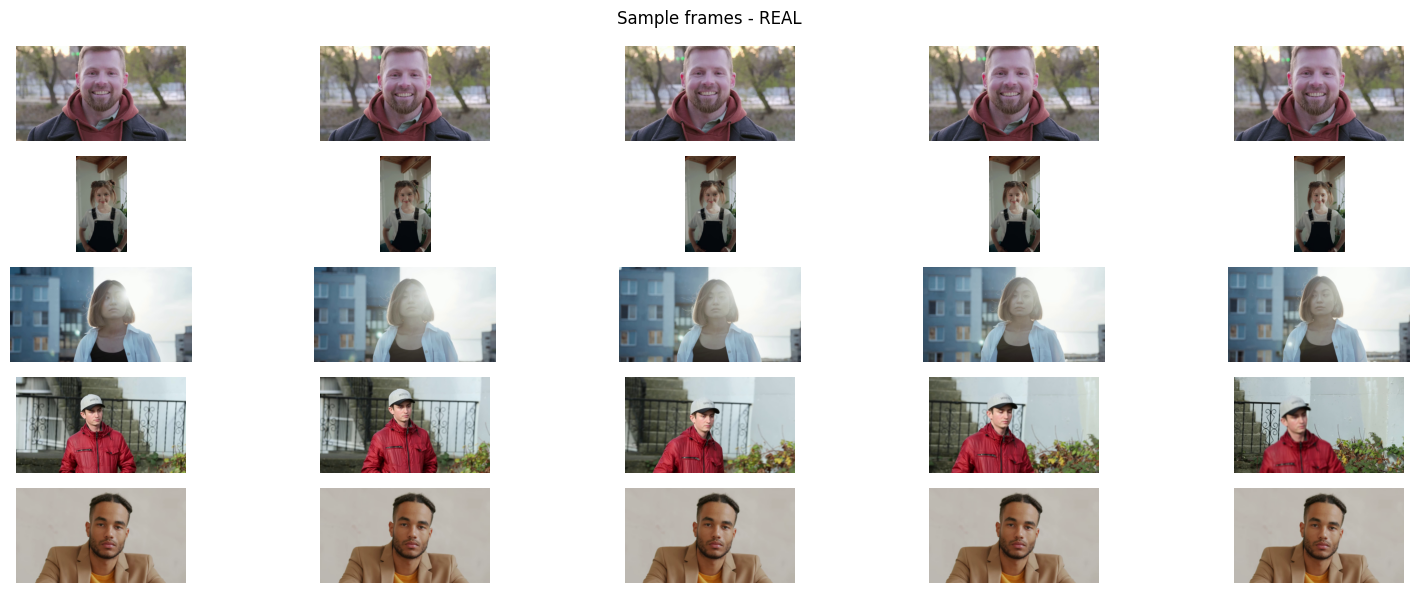

In [ ]:
real_samples = real_videos[:SAMPLE_VIDEOS_PER_CLASS]
all_real_frames = []
for v in real_samples:
    frs = sample_frames_from_video(v, n_frames=FRAMES_PER_VIDEO)
    all_real_frames += frs
make_grid(all_real_frames, cols=FRAMES_PER_VIDEO, title="Sample frames - REAL")

In [ ]:
detector = MTCNN()
def detect_faces_in_image(img_rgb, max_faces=3):
    try:
        dets = detector.detect_faces(img_rgb)
    except Exception:
        return []
    dets = sorted(dets, key=lambda x: x['box'][2]*x['box'][3], reverse=True)[:max_faces]
    crops=[]
    for d in dets:
        x,y,w,h = d['box']
        x,y = max(0,x), max(0,y)
        crop = img_rgb[y:y+h, x:x+w]
        if crop.size==0:
            continue
        crop = cv2.resize(crop, (224,224))
        crops.append(crop)
    return crops

In [ ]:
FAKE_FRAMES_TO_SCAN = all_fake_frames[:10]
REAL_FRAMES_TO_SCAN = all_real_frames[:10]

face crops found - fake: 11 real: 10


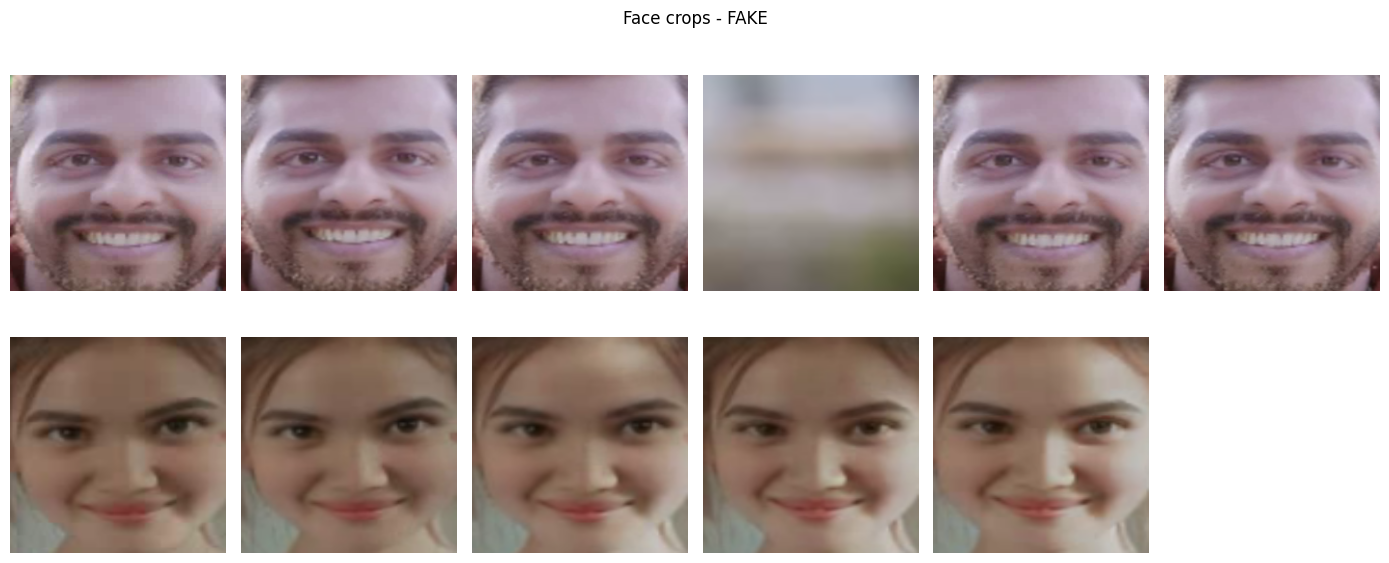

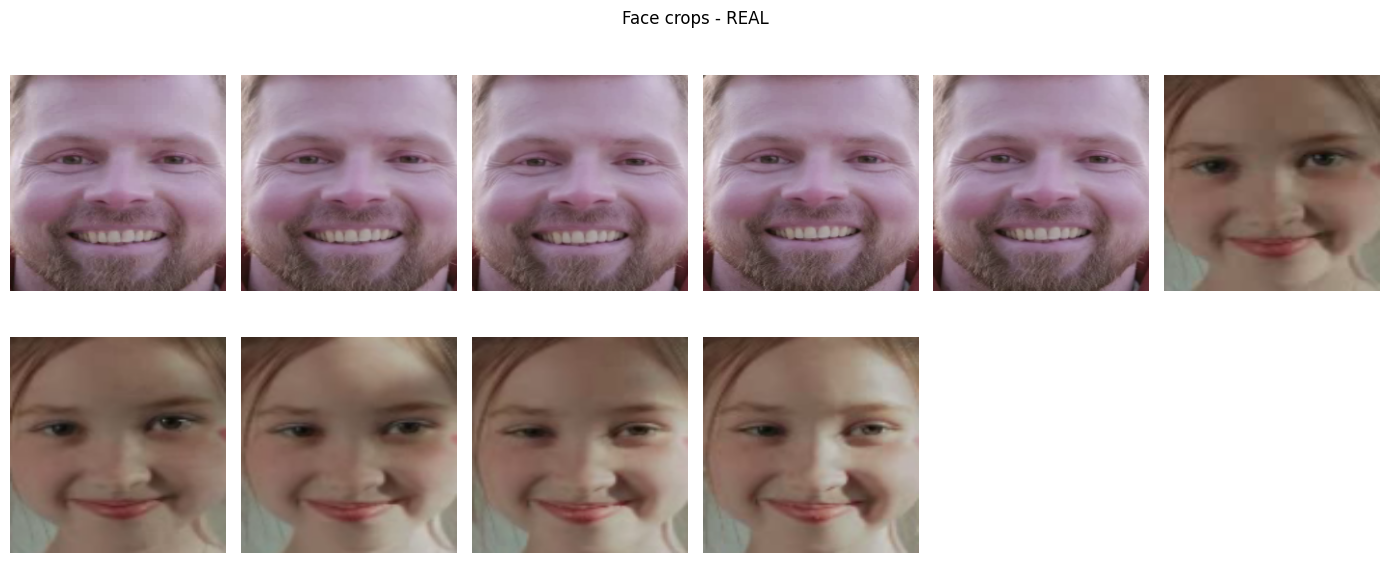

In [ ]:
fake_crops=[]
for im in FAKE_FRAMES_TO_SCAN:
    fake_crops += detect_faces_in_image(im, max_faces=2)
real_crops=[]
for im in REAL_FRAMES_TO_SCAN:
    real_crops += detect_faces_in_image(im, max_faces=2)

print("face crops found - fake:", len(fake_crops), "real:", len(real_crops))
make_grid(fake_crops[:12], cols=6, title="Face crops - FAKE", figsize=(14,6))
make_grid(real_crops[:12], cols=6, title="Face crops - REAL", figsize=(14,6))

In [ ]:
def create_summary_df(fake_list, real_list, n=500):
    rows=[]
    for p in fake_list[:n]:
        info = video_info(p)
        if info: rows.append({"class":"fake", **info})
    for p in real_list[:n]:
        info = video_info(p)
        if info: rows.append({"class":"real", **info})
    return pd.DataFrame(rows)

In [ ]:
summary_df = create_summary_df(fake_videos, real_videos, n=500)
summary_csv = "/content/deepfake_dataset_summary.csv"
summary_df.to_csv(summary_csv, index=False)
print("Saved summary csv ->", summary_csv)
display(summary_df.head())

Saved summary csv -> /content/deepfake_dataset_summary.csv


,class,path,fps,frames,duration,width,height
0,fake,/content/deepfake-dataset/SDFVD/videos_fake/vs...,30.0,82,2.733333,1280,720
1,fake,/content/deepfake-dataset/SDFVD/videos_fake/vs...,30.0,110,3.666667,378,720
2,fake,/content/deepfake-dataset/SDFVD/videos_fake/vs...,30.0,82,2.733333,1280,674
3,fake,/content/deepfake-dataset/SDFVD/videos_fake/vs...,30.0,101,3.366667,1280,720
4,fake,/content/deepfake-dataset/SDFVD/videos_fake/vs...,30.0,81,2.700000,1280,720


In [ ]:
print("Suggested train/val split (80/20) counts:")
total_fake = len(fake_videos); total_real = len(real_videos)
print("fake -> train:", int(0.8*total_fake), "val:", total_fake - int(0.8*total_fake))
print("real -> train:", int(0.8*total_real), "val:", total_real - int(0.8*total_real))

Suggested train/val split (80/20) counts:
fake -> train: 42 val: 11
real -> train: 42 val: 11


In [ ]:
print("DATA_ROOT:", DATA_ROOT)
print("fake vids:", len(fake_videos), "real vids:", len(real_videos))

fake vids: 53 real vids: 53


In [ ]:
import shutil

In [ ]:
# 3) params and output folders
FRAMES_PER_VIDEO = 10      # frames to sample per video
IMG_SIZE = (299,299)       # Xception input
TRAIN_SPLIT = 0.8
BATCH_SIZE = 16
EPOCHS = 12
OUT_DIR = "/content/deepfake_frames_continued"
FRAME_SAVE_DIR = os.path.join(OUT_DIR, "frames_by_label")
if os.path.exists(OUT_DIR):
    # comment the next line if you want to keep existing frames
    shutil.rmtree(OUT_DIR)
os.makedirs(FRAME_SAVE_DIR, exist_ok=True)

In [ ]:
detector = MTCNN()

def extract_face_rgb(img_bgr, required_size=IMG_SIZE):
    if img_bgr is None:
        return None
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    try:
        dets = detector.detect_faces(img_rgb)
    except Exception:
        dets = []
    if not dets:
        return None
    box = max(dets, key=lambda x: x['box'][2]*x['box'][3])['box']
    x,y,w,h = box
    x,y = max(0,int(x)), max(0,int(y))
    face = img_rgb[y:y+int(h), x:x+int(w)]
    if face.size == 0:
        return None
    face = cv2.resize(face, required_size)
    return face

def sample_frames_from_video_and_save(video_path, out_dir, n_frames=10):
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT) or 0)
    if total <= 0:
        cap.release(); return 0
    idxs = np.linspace(0, total-1, min(n_frames, total), dtype=int)
    saved = 0
    base = os.path.splitext(os.path.basename(video_path))[0]
    for idx in idxs:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ret, frame = cap.read()
        if not ret: continue
        face = extract_face_rgb(frame, required_size=IMG_SIZE)
        if face is None:
            h,w = frame.shape[:2]
            c = frame[h//4:3*h//4, w//4:3*w//4]
            if c.size == 0: continue
            face = cv2.resize(cv2.cvtColor(c, cv2.COLOR_BGR2RGB), IMG_SIZE)
        fname = f"{base}_{idx}_{random.randint(0, int(1e9))}.jpg"
        cv2.imwrite(os.path.join(out_dir, fname), cv2.cvtColor(face, cv2.COLOR_RGB2BGR))
        saved += 1
    cap.release()
    return saved

In [ ]:
def process_videos(video_list, label, out_root=FRAME_SAVE_DIR, frames_per_video=FRAMES_PER_VIDEO, split_ratio=TRAIN_SPLIT):
    random.shuffle(video_list)
    n_train = int(len(video_list) * split_ratio)
    train_v = video_list[:n_train]
    val_v = video_list[n_train:]
    for split_name, vlist in [("train", train_v), ("val", val_v)]:
        out_dir = os.path.join(out_root, split_name, label)
        os.makedirs(out_dir, exist_ok=True)
        for v in tqdm(vlist, desc=f"{label} {split_name}", unit="vid"):
            sample_frames_from_video_and_save(v, out_dir, n_frames=frames_per_video)

# 5) extract frames for both classes (will create train/val/{real,fake})
process_videos(fake_videos, "fake")
process_videos(real_videos, "real")

real val: 100%|██████████| 11/11 [00:51<00:00,  4.69s/vid]


In [ ]:
for split in ["train","val"]:
    p = os.path.join(FRAME_SAVE_DIR, split)
    if not os.path.exists(p): continue
    for cls in sorted(os.listdir(p)):
        c = len([f for f in os.listdir(os.path.join(p,cls)) if f.lower().endswith(('.jpg','.png'))])
        print(f"{split}/{cls}: {c}")

train/fake: 420
train/real: 420
val/fake: 110
val/real: 110


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(rescale=1./255,
                                   rotation_range=10, width_shift_range=0.08, height_shift_range=0.08,
                                   zoom_range=0.1, horizontal_flip=True)
val_datagen = ImageDataGenerator(rescale=1./255)

train_dir = os.path.join(FRAME_SAVE_DIR, "train")
val_dir   = os.path.join(FRAME_SAVE_DIR, "val")

In [ ]:
train_gen = train_datagen.flow_from_directory(train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary', shuffle=True, seed=42)
val_gen   = val_datagen.flow_from_directory(val_dir,   target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary', shuffle=False)

Found 840 images belonging to 2 classes.
Found 220 images belonging to 2 classes.


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
y_train = train_gen.classes
classes = np.unique(y_train)
cw_vals = compute_class_weight("balanced", classes=classes, y=y_train)
class_weight = {int(classes[i]): float(cw_vals[i]) for i in range(len(classes))}
print("class_weight:", class_weight)

class_weight: {0: 1.0, 1: 1.0}


In [ ]:
from tensorflow.keras.applications import Xception
from tensorflow.keras import layers, models

def build_xception(input_shape=(*IMG_SIZE,3), lr=1e-4):
    base = Xception(weights='imagenet', include_top=False, input_shape=input_shape)
    base.trainable = False
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    model = models.Model(inputs=base.input, outputs=out)
    model.compile(optimizer=tf.keras.optimizers.Adam(lr), loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    return model


In [ ]:
model = build_xception()
model.summary()

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 149, 149,  │        864 │ input_layer_6[0]… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_bn     │ (None, 149, 149,  │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_act    │ (None, 149, 149,  │          0 │ block1_conv1_bn[… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 147, 147,  │     18,432 │ block1_conv1_act… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_bn     │ (None, 147, 147,  │        256 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_act    │ (None, 147, 147,  │          0 │ block1_conv2_bn[… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1     │ (None, 147, 147,  │      8,768 │ block1_conv2_act… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1_bn  │ (None, 147, 147,  │        512 │ block2_sepconv1[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_act │ (None, 147, 147,  │          0 │ block2_sepconv1_… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2     │ (None, 147, 147,  │     17,536 │ block2_sepconv2_… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_bn  │ (None, 147, 147,  │        512 │ block2_sepconv2[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 74, 74,    │      8,192 │ block1_conv2_act… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 74, 74,    │          0 │ block2_sepconv2_… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 74, 74,    │        512 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 74, 74,    │          0 │ block2_pool[0][0… │
│                     │ 128)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_sepconv1_act │ (None, 74, 74,    │          0 │ add[0][0]       

 Total params: 21,386,281 (81.58 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 20,861,480 (79.58 MB)

In [ ]:
ckpt = os.path.join(OUT_DIR, "xception_best.h5")
cbs = [
    tf.keras.callbacks.ModelCheckpoint(ckpt, save_best_only=True, monitor='val_loss', verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-7, verbose=1)
]

history = model.fit(train_gen, validation_data=val_gen, epochs=EPOCHS, class_weight=class_weight, callbacks=cbs)

Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.


Epoch 1/12
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 757ms/step - accuracy: 0.6142 - auc: 0.6581 - loss: 0.6531
Epoch 1: val_loss improved from inf to 0.61682, saving model to /content/deepfake_frames_continued/xception_best.h5


53/53 ━━━━━━━━━━━━━━━━━━━━ 110s 1s/step - accuracy: 0.6148 - auc: 0.6590 - loss: 0.6527 - val_accuracy: 0.6364 - val_auc: 0.7917 - val_loss: 0.6168 - learning_rate: 1.0000e-04
Epoch 2/12
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step - accuracy: 0.7622 - auc: 0.8328 - loss: 0.5452
Epoch 2: val_loss improved from 0.61682 to 0.55777, saving model to /content/deepfake_frames_continued/xception_best.h5


53/53 ━━━━━━━━━━━━━━━━━━━━ 21s 400ms/step - accuracy: 0.7625 - auc: 0.8331 - loss: 0.5448 - val_accuracy: 0.7682 - val_auc: 0.8304 - val_loss: 0.5578 - learning_rate: 1.0000e-04
Epoch 3/12
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step - accuracy: 0.8150 - auc: 0.8764 - loss: 0.4746
Epoch 3: val_loss improved from 0.55777 to 0.53090, saving model to /content/deepfake_frames_continued/xception_best.h5


53/53 ━━━━━━━━━━━━━━━━━━━━ 21s 404ms/step - accuracy: 0.8150 - auc: 0.8765 - loss: 0.4744 - val_accuracy: 0.7364 - val_auc: 0.8336 - val_loss: 0.5309 - learning_rate: 1.0000e-04
Epoch 4/12
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step - accuracy: 0.8425 - auc: 0.9105 - loss: 0.4163
Epoch 4: val_loss improved from 0.53090 to 0.52949, saving model to /content/deepfake_frames_continued/xception_best.h5


53/53 ━━━━━━━━━━━━━━━━━━━━ 20s 377ms/step - accuracy: 0.8423 - auc: 0.9105 - loss: 0.4164 - val_accuracy: 0.7045 - val_auc: 0.8231 - val_loss: 0.5295 - learning_rate: 1.0000e-04
Epoch 5/12
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step - accuracy: 0.8293 - auc: 0.9039 - loss: 0.4159
Epoch 5: val_loss improved from 0.52949 to 0.51669, saving model to /content/deepfake_frames_continued/xception_best.h5


53/53 ━━━━━━━━━━━━━━━━━━━━ 21s 402ms/step - accuracy: 0.8295 - auc: 0.9042 - loss: 0.4156 - val_accuracy: 0.7318 - val_auc: 0.8260 - val_loss: 0.5167 - learning_rate: 1.0000e-04
Epoch 6/12
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step - accuracy: 0.8469 - auc: 0.9300 - loss: 0.3667
Epoch 6: val_loss improved from 0.51669 to 0.50474, saving model to /content/deepfake_frames_continued/xception_best.h5


53/53 ━━━━━━━━━━━━━━━━━━━━ 20s 387ms/step - accuracy: 0.8470 - auc: 0.9301 - loss: 0.3666 - val_accuracy: 0.7591 - val_auc: 0.8368 - val_loss: 0.5047 - learning_rate: 1.0000e-04
Epoch 7/12
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - accuracy: 0.8635 - auc: 0.9476 - loss: 0.3405
Epoch 7: val_loss did not improve from 0.50474
53/53 ━━━━━━━━━━━━━━━━━━━━ 20s 369ms/step - accuracy: 0.8636 - auc: 0.9475 - loss: 0.3404 - val_accuracy: 0.7136 - val_auc: 0.8465 - val_loss: 0.5518 - learning_rate: 1.0000e-04
Epoch 8/12
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step - accuracy: 0.8573 - auc: 0.9444 - loss: 0.3276
Epoch 8: val_loss improved from 0.50474 to 0.50116, saving model to /content/deepfake_frames_continued/xception_best.h5


53/53 ━━━━━━━━━━━━━━━━━━━━ 21s 400ms/step - accuracy: 0.8574 - auc: 0.9442 - loss: 0.3279 - val_accuracy: 0.7818 - val_auc: 0.8387 - val_loss: 0.5012 - learning_rate: 1.0000e-04
Epoch 9/12
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step - accuracy: 0.8625 - auc: 0.9275 - loss: 0.3537
Epoch 9: val_loss improved from 0.50116 to 0.49723, saving model to /content/deepfake_frames_continued/xception_best.h5


53/53 ━━━━━━━━━━━━━━━━━━━━ 21s 387ms/step - accuracy: 0.8629 - auc: 0.9278 - loss: 0.3531 - val_accuracy: 0.7727 - val_auc: 0.8414 - val_loss: 0.4972 - learning_rate: 1.0000e-04
Epoch 10/12
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step - accuracy: 0.8569 - auc: 0.9452 - loss: 0.3203
Epoch 10: val_loss did not improve from 0.49723
53/53 ━━━━━━━━━━━━━━━━━━━━ 20s 370ms/step - accuracy: 0.8571 - auc: 0.9453 - loss: 0.3202 - val_accuracy: 0.7455 - val_auc: 0.8469 - val_loss: 0.5093 - learning_rate: 1.0000e-04
Epoch 11/12
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step - accuracy: 0.8865 - auc: 0.9504 - loss: 0.3043
Epoch 11: val_loss did not improve from 0.49723
53/53 ━━━━━━━━━━━━━━━━━━━━ 21s 395ms/step - accuracy: 0.8864 - auc: 0.9504 - loss: 0.3043 - val_accuracy: 0.7636 - val_auc: 0.8381 - val_loss: 0.5050 - learning_rate: 1.0000e-04
Epoch 12/12
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - accuracy: 0.9008 - auc: 0.9597 - loss: 0.2782
Epoch 12: val_loss did not improve from 0.49723

Epoch 12: ReduceLR

In [ ]:
os.makedirs(OUT_DIR, exist_ok=True)
model.save(os.path.join(OUT_DIR, "xception_deepfake_final.h5"))
import pickle
with open(os.path.join(OUT_DIR, "xception_history.pkl"), "wb") as f:
    pickle.dump({"history": getattr(history,'history',None)}, f)
print("Saved model & history to", OUT_DIR)

Saved model & history to /content/deepfake_frames_continued


In [ ]:
val_gen_reset = val_datagen.flow_from_directory(val_dir, target_size=IMG_SIZE, batch_size=1, class_mode='binary', shuffle=False)
N_EVAL = min(200, val_gen_reset.samples)
preds = model.predict(val_gen_reset, steps=N_EVAL, verbose=1)
pred_labels = (preds.flatten() >= 0.5).astype(int)
true_labels = val_gen_reset.classes[:len(pred_labels)]
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(true_labels, pred_labels))
print("Confusion matrix:\n", confusion_matrix(true_labels, pred_labels))

Found 220 images belonging to 2 classes.
200/200 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step
              precision    recall  f1-score   support

           0       0.86      0.75      0.80       110
           1       0.74      0.84      0.79        90

    accuracy                           0.80       200
   macro avg       0.80      0.80      0.79       200
weighted avg       0.80      0.80      0.80       200

Confusion matrix:
 [[83 27]
 [14 76]]


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0

In [ ]:
def make_model_without_lambda(img_size=(224, 224, 3), lr=1e-4):
    """Create EfficientNet model without Lambda layer"""
    inp = layers.Input(shape=img_size)

    # Create base model with preprocessing built-in
    base_model = EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_shape=img_size,
        input_tensor=inp  # Pass input directly
    )
    base_model.trainable = False

    # Get the output from base model
    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs=inp, outputs=out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC()]
    )
    return model

In [ ]:
def rebuild_and_save_model(old_model_path, new_model_path):
    """Rebuild model and transfer weights"""
    try:
        # Load the old model with unsafe mode
        tf.keras.config.enable_unsafe_deserialization()
        old_model = tf.keras.models.load_model(old_model_path, safe_mode=False)

        # Create new model without Lambda layer
        new_model = make_model_without_lambda()

        # Get weights from old model (skip the Lambda layer)
        old_weights = old_model.get_weights()

        # Set weights to new model (may need adjustment depending on layer structure)
        # This assumes the Lambda layer is the first layer and we skip it
        try:
            new_model.set_weights(old_weights[2:])  # Skip first 2 layers (input and lambda)
        except:
            # Alternative: manually map layers
            for i, layer in enumerate(new_model.layers):
                if hasattr(layer, 'get_weights') and layer.get_weights():
                    try:
                        # Find corresponding layer in old model
                        old_layer = old_model.layers[i + 1]  # Account for skipped Lambda layer
                        if old_layer.get_weights():
                            layer.set_weights(old_layer.get_weights())
                    except:
                        continue

        # Save the new model
        new_model.save(new_model_path)
        print(f"Model rebuilt and saved to {new_model_path}")
        return new_model

    except Exception as e:
        print(f"Error rebuilding model: {str(e)}")
        return None

In [ ]:
# Run this once to create a fixed model
new_model = rebuild_and_save_model("best_model.h5", "/content/best_model_fixed.h5")

# Then update your FastAPI model path to use the fixed model
FACE_SPOOF_MODEL_PATH = "best_model_fixed.h5"

Error rebuilding model: Exception encountered when calling Lambda.call().

We could not automatically infer the shape of the Lambda's output. Please specify the `output_shape` argument for this Lambda layer.

Arguments received by Lambda.call():
  • args=('<KerasTensor shape=(None, 224, 224, 3), dtype=float32, sparse=False, ragged=False, name=input_layer>',)
  • kwargs={'mask': 'None'}
